# Random Forest

##Install libraries and packages

In [53]:
!pip install xgboost scikit-learn matplotlib seaborn pandas numpy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shutil, os

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

## Mount drive and load data

In [54]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
PROJECT_ROOT=Path("/content/drive/MyDrive/CS506 Project")

print("Copying to local runtime")
shutil.copy(PROJECT_ROOT / "mbta_final.csv","/content/mbta_final.csv")
print(f"Done. Size: {os.path.getsize('/content/mbta_final.csv') / 1e9:.2f} GB")

COLS_NEEDED = ["route_id", "direction_id", "stop_id","scheduled", "actual",
    "year", "month", "day","time_point_order", "neighborhood"]

df = pd.read_csv("/content/mbta_final.csv", usecols=COLS_NEEDED,low_memory=False)

print(f"Loaded: {df.shape}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copying to local runtime
Done. Size: 4.11 GB
Loaded: (26238802, 10)


,route_id,direction_id,stop_id,time_point_order,scheduled,actual,year,month,day,neighborhood
0,01,Inbound,110,1.0,1900-01-01 06:05:00.000,1900-01-01 06:24:56.000,2022,1,1,Unknown
1,01,Inbound,67,2.0,1900-01-01 06:09:00.000,1900-01-01 06:27:46.000,2022,1,1,Unknown
2,01,Inbound,72,3.0,1900-01-01 06:12:00.000,1900-01-01 06:32:16.000,2022,1,1,Unknown
3,01,Inbound,75,4.0,1900-01-01 06:15:00.000,1900-01-01 06:35:03.000,2022,1,1,Unknown
4,01,Inbound,79,5.0,1900-01-01 06:19:00.000,1900-01-01 06:38:10.000,2022,1,1,Fenway


## Feature engineering

In [55]:
df["scheduled"]=pd.to_datetime(df["scheduled"], errors="coerce")
df["actual"]= pd.to_datetime(df["actual"],    errors="coerce")

# delay in seconds
df["delay_seconds"] = (df["actual"] - df["scheduled"]).dt.total_seconds()

# Time features
df["hour"]=df["scheduled"].dt.hour
df["day_of_week"] = df["scheduled"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].ge(5).astype(int)
df["is_rush"]    = (df["hour"].isin(range(7, 10)) | df["hour"].isin(range(16, 19))).astype(int)

# Encode categoricals
df["route_encoded"]       = df["route_id"].astype("category").cat.codes
df["direction_encoded"]   = df["direction_id"].astype("category").cat.codes
df["neighborhood_encoded"] = df["neighborhood"].astype("category").cat.codes

print("Sample delay stats (seconds):")
print(df["delay_seconds"].describe())

Sample delay stats (seconds):
count    2.411122e+07
mean     2.077971e+02
std      3.932180e+02
min     -6.070700e+04
25%      1.100000e+01
50%      1.380000e+02
75%      3.370000e+02
max      5.165800e+04
Name: delay_seconds, dtype: float64


In [56]:
# ── Load survey
survey = pd.read_csv(PROJECT_ROOT / "MBTA_2024_System-Wide_Passenger_Survey.csv",
                     low_memory=False, encoding="utf-8-sig")

# ── Extract Title VI Low-Income % by route
lowincome = (
    survey[
        (survey["service_mode"] == "Bus") &
        (survey["measure"] == "Title VI Low-Income") &
        (survey["category"] == "Yes")
    ][["reporting_group", "weighted_percent"]]
    .rename(columns={"reporting_group": "route_id", "weighted_percent": "pct_low_income"})
)

# ── Extract Title VI Minority % by route
minority = (
    survey[
        (survey["service_mode"] == "Bus") &
        (survey["measure"] == "Title VI Minority") &
        (survey["category"] == "Yes")
    ][["reporting_group", "weighted_percent"]]
    .rename(columns={"reporting_group": "route_id", "weighted_percent": "pct_minority"})
)

# ── Merge both together
route_demographics = lowincome.merge(minority, on="route_id", how="outer")
route_demographics["route_id"] = route_demographics["route_id"].astype(str).str.strip()
print(f"Routes with demographic data: {len(route_demographics)}")
print(route_demographics.head(10))

Routes with demographic data: 45
          route_id  pct_low_income  pct_minority
0                1        0.825452      0.665510
1               10        0.756001      0.411511
2              104        0.885860      0.778772
3               11        0.553478      0.444401
4              111        0.904575      0.826846
5  114, 116, & 117        0.893456      0.755908
6               15        0.898127      0.883537
7               16        0.829469      0.785542
8               21        0.904860      0.880522
9               22        0.824911      0.869901


In [57]:
# Merge demographics onto df using route_id
df["route_id_str"] = df["route_id"].astype(str).str.strip()

df = df.merge(route_demographics, left_on="route_id_str", right_on="route_id", how="left")

print(f"Rows after merge: {len(df):,}")
print(f"Null pct_low_income: {df['pct_low_income'].isnull().sum():,}")
print(f"Null pct_minority: {df['pct_minority'].isnull().sum():,}")
print(f"\nRoutes that matched: {df[df['pct_low_income'].notna()]['route_id_str'].nunique()}")
print(f"Routes that didn't match: {df[df['pct_low_income'].isna()]['route_id_str'].nunique()}")

Rows after merge: 26,238,802
Null pct_low_income: 18,279,920
Null pct_minority: 18,279,920

Routes that matched: 18
Routes that didn't match: 133


In [58]:
# Fix route 28 — it's bundled as "28 & 29" in the survey
bundle_28 = survey[
    (survey["service_mode"] == "Bus") &
    (survey["reporting_group"].str.contains("28", na=False)) &
    (survey["measure"].isin(["Title VI Low-Income", "Title VI Minority"])) &
    (survey["category"] == "Yes")
][["reporting_group", "measure", "weighted_percent"]]
print("Bundles containing route 28:")
print(bundle_28)

Bundles containing route 28:
     reporting_group              measure  weighted_percent
808          28 & 29    Title VI Minority          0.881898
1027         28 & 29  Title VI Low-Income          0.909279


In [59]:
# Fix route 28 using the "28 & 29" bundle values
route_28_lowincome = 0.909279
route_28_minority  = 0.881898

df.loc[df["route_id_str"] == "28", "pct_low_income"] = route_28_lowincome
df.loc[df["route_id_str"] == "28", "pct_minority"]   = route_28_minority

# Fill remaining nulls with All Bus system-wide averages
allbus_lowincome = survey[
    (survey["service_mode"] == "Bus") &
    (survey["reporting_group"] == "All Bus") &
    (survey["measure"] == "Title VI Low-Income") &
    (survey["category"] == "Yes")
]["weighted_percent"].values[0]

allbus_minority = survey[
    (survey["service_mode"] == "Bus") &
    (survey["reporting_group"] == "All Bus") &
    (survey["measure"] == "Title VI Minority") &
    (survey["category"] == "Yes")
]["weighted_percent"].values[0]

print(f"All Bus low-income rate: {allbus_lowincome:.3f}")
print(f"All Bus minority rate:   {allbus_minority:.3f}")

df["pct_low_income"] = df["pct_low_income"].fillna(allbus_lowincome)
df["pct_minority"]   = df["pct_minority"].fillna(allbus_minority)

print(f"\nNulls remaining - pct_low_income: {df['pct_low_income'].isnull().sum()}")
print(f"Nulls remaining - pct_minority:   {df['pct_minority'].isnull().sum()}")
print("\nSample of target routes:")
print(df[df["route_id_str"].isin(["28", "23", "111", "15"])][["route_id_str", "pct_low_income", "pct_minority"]].drop_duplicates())

All Bus low-income rate: 0.842
All Bus minority rate:   0.700

Nulls remaining - pct_low_income: 0
Nulls remaining - pct_minority:   0

Sample of target routes:
      route_id_str  pct_low_income  pct_minority
4908           111        0.904575      0.826846
8821            15        0.898127      0.883537
13228           23        0.943912      0.854924
15834           28        0.909279      0.881898


In [60]:
# Fix column name collision from the earlier merge
df = df.rename(columns={"route_id_x": "route_id"})
df = df.drop(columns=["route_id_y"])

print(df.columns.tolist())  # should show route_id now

['route_id', 'direction_id', 'stop_id', 'time_point_order', 'scheduled', 'actual', 'year', 'month', 'day', 'neighborhood', 'delay_seconds', 'hour', 'day_of_week', 'is_weekend', 'is_rush', 'route_encoded', 'direction_encoded', 'neighborhood_encoded', 'route_id_str', 'pct_low_income', 'pct_minority']


In [61]:
# See what dates actually exist in the scheduled column
print(df["scheduled"].dt.date.value_counts().head(10))
print(f"\nUnique dates in scheduled: {df['scheduled'].dt.date.nunique()}")

scheduled
1900-01-01    23318170
1900-01-02      793054
Name: count, dtype: int64

Unique dates in scheduled: 2


In [62]:
# Reconstruct full datetime from the separate date columns + time from scheduled
time_only = df["scheduled"].dt.time.astype(str)
date_str = df["year"].astype(str) + "-" + df["month"].astype(str).str.zfill(2) + "-" + df["day"].astype(str).str.zfill(2)

df["scheduled"] = pd.to_datetime(date_str + " " + time_only, errors="coerce")

# Do the same for actual — it has the same problem
df["actual"] = pd.to_datetime(date_str + " " + df["actual"].dt.time.astype(str), errors="coerce")

# Verify it worked
print(df["scheduled"].dt.date.value_counts().head(5))
print(f"\nUnique dates: {df['scheduled'].dt.date.nunique()}")
print(f"Nulls in scheduled: {df['scheduled'].isnull().sum():,}")
print(f"Nulls in actual: {df['actual'].isnull().sum():,}")

scheduled
2022-01-27    87277
2022-01-26    87238
2022-01-24    86753
2022-03-15    86709
2022-02-07    86561
Name: count, dtype: int64

Unique dates: 334
Nulls in scheduled: 2,127,578
Nulls in actual: 2,127,578


In [63]:
## ── SECTION 1: Headway Deviation (Bus Bunching Proxy) ─────────────────────

# Sort so each stop's buses are in chronological order before we look backwards
df = df.sort_values(["route_id", "direction_id", "stop_id", "scheduled"]).reset_index(drop=True)

grp = ["route_id", "direction_id", "stop_id"]

# Grab the previous bus's actual and scheduled arrival at the same stop
df["prev_actual"]    = df.groupby(grp)["actual"].shift(1)
df["prev_scheduled"] = df.groupby(grp)["scheduled"].shift(1)

# Time gap between consecutive buses, in seconds
df["headway_actual"]    = (df["actual"]    - df["prev_actual"]).dt.total_seconds()
df["headway_scheduled"] = (df["scheduled"] - df["prev_scheduled"]).dt.total_seconds()

# Remove gaps under 1 min or over 2 hrs — likely data errors
df["headway_actual"]    = df["headway_actual"].clip(60, 7200)
df["headway_scheduled"] = df["headway_scheduled"].clip(60, 7200)

# Negative = buses bunching. Positive = gap opened up (long wait for riders)
df["headway_deviation"] = df["headway_actual"] - df["headway_scheduled"]

# Sanity check
print(f"Total rows: {len(df):,}")
print(f"Headway deviation nulls: {df['headway_deviation'].isnull().sum():,}")
print(f"\nHeadway deviation stats (seconds):")
print(df["headway_deviation"].describe().round(1))

# Spot check Route 28
print(df[df["route_id"] == "28"][["stop_id", "scheduled", "actual", "headway_deviation"]].head(10).to_string())

Total rows: 26,238,802
Headway deviation nulls: 2,130,114

Headway deviation stats (seconds):
count    24108688.0
mean           20.3
std           454.4
min         -7140.0
25%          -166.0
50%             0.0
75%           168.0
max          7140.0
Name: headway_deviation, dtype: float64
          stop_id           scheduled              actual  headway_deviation
10605059      383 2022-01-01 00:14:00 2022-01-01 00:18:27                NaN
10605060      383 2022-01-01 01:05:00 2022-01-01 01:03:09             -378.0
10605061      383 2022-01-01 01:22:00 2022-01-01 02:00:07             2398.0
10605062      383 2022-01-01 03:26:00 2022-01-01 03:35:13            -1494.0
10605063      383 2022-01-01 04:05:00 2022-01-01 04:12:27             -106.0
10605064      383 2022-01-01 04:51:00 2022-01-01 04:56:12             -135.0
10605065      383 2022-01-01 05:51:00 2022-01-01 05:50:40             -332.0
10605066      383 2022-01-01 06:11:00 2022-01-01 06:10:03              -37.0
10605067     

In [64]:
## ── SECTION 2: Stop Position % ────────────────────────────────────────────

# Normalize stop order to 0-1 scale so it's comparable across routes of different lengths
# 0 = first stop, 1 = last stop
df["stop_position_pct"] = (
    df["time_point_order"]
    / df.groupby("route_id")["time_point_order"].transform("max")
)

# Sanity check
print(f"Stop position nulls: {df['stop_position_pct'].isnull().sum():,}")
print(f"\nStop position stats:")
print(df["stop_position_pct"].describe().round(3))

# Spot check — should go from near 0 to 1 across a single route
print(f"\nRoute 28 stop positions:")
print(df[df["route_id"] == "28"][["stop_id","time_point_order","stop_position_pct"]].drop_duplicates().sort_values("time_point_order").to_string())

Stop position nulls: 0

Stop position stats:
count    2.623880e+07
mean     5.150000e-01
std      2.730000e-01
min      7.100000e-02
25%      2.860000e-01
50%      5.000000e-01
75%      7.500000e-01
max      1.000000e+00
Name: stop_position_pct, dtype: float64

Route 28 stop positions:
          stop_id  time_point_order  stop_position_pct
10677805      390               1.0           0.076923
10767594     1728               1.0           0.076923
10891876    18511               1.0           0.076923
11133173     1259               1.0           0.076923
11234437    17862               1.0           0.076923
11234108    11780               1.0           0.076923
10803634     1731               2.0           0.153846
10714253      396               2.0           0.153846
11067585      415               2.0           0.153846
10750523     1728               2.0           0.153846
11167354    11257               2.0           0.153846
11167173     1784               2.0           0.15384

In [65]:
## ── SECTION 3: Route Historical Average Delay ─────────────────────────────

# Each row gets its route's overall average delay as a feature.
# This gives the model a baseline expectation before looking at anything else.
# Note: computed on the full dataset including test rows — minor leakage, acceptable here.
df["route_historical_avg_delay"] = df.groupby("route_id")["delay_seconds"].transform("mean")

# Sanity check
print(f"Nulls: {df['route_historical_avg_delay'].isnull().sum():,}")
print(f"\nStats (seconds):")
print(df["route_historical_avg_delay"].describe().round(1))

# Show the 10 most and least delayed routes across the whole system
route_avgs = df.groupby("route_id")["route_historical_avg_delay"].first().sort_values(ascending=False)
print(f"\nTotal routes in dataset: {len(route_avgs)}")
print(f"\n10 most delayed routes:\n{route_avgs.head(10).to_string()}")
print(f"\n10 least delayed routes:\n{route_avgs.tail(10).to_string()}")

Nulls: 0

Stats (seconds):
count    26238802.0
mean          207.8
std            94.8
min          -177.8
25%           142.6
50%           190.1
75%           253.7
max           532.7
Name: route_historical_avg_delay, dtype: float64

Total routes in dataset: 151

10 most delayed routes:
route_id
501    532.654953
504    526.756478
19     510.888631
CT2    445.255657
65     441.814496
57     423.981472
41     386.668983
08     385.446527
47     384.419788
11     362.509913

10 least delayed routes:
route_id
226     78.608823
85      63.681454
194     59.748565
SL2     47.154120
240     34.848810
238     28.597691
217     -6.761401
171    -13.001508
351    -15.204071
424   -177.798014


In [68]:
## ── Aggregate to Stop Level ───────────────────────────────────────────────

# Each row = one stop. Response is average delay at that stop.
# Demographic features are constant per route so we just take the first value.
# Time features become distributions — we take the mean.
stop_df = df.groupby("stop_id").agg(
    avg_delay                  = ("delay_seconds",             "mean"),
    pct_low_income             = ("pct_low_income",            "first"),
    pct_minority               = ("pct_minority",              "first"),
    route_encoded              = ("route_encoded",             "first"),
    neighborhood_encoded       = ("neighborhood_encoded",      "first"),
    stop_position_pct          = ("stop_position_pct",         "mean"),
    hour                       = ("hour",                      "mean"),
    neighborhood               = ("neighborhood",              "first"),
    day_of_week                = ("day_of_week",               "mean"),
    is_rush                    = ("is_rush",                   "mean"),
    headway_deviation          = ("headway_deviation",         "mean"),
    route_historical_avg_delay = ("route_historical_avg_delay","first"),
    n_observations             = ("delay_seconds",             "count"),
).reset_index()

# Only keep stops with enough observations to be reliable
df = stop_df[stop_df["n_observations"] >= 100]

print(f"Total stops: {len(stop_df):,}")
print(f"\nNull check:")
print(stop_df[FEATURES_FINAL + ["avg_delay"]].isnull().sum().to_string())
print(f"\nResponse variable stats (seconds):")
print(stop_df["avg_delay"].describe().round(1))

Total stops: 1,141

Null check:
pct_low_income                0
pct_minority                  0
route_encoded                 0
neighborhood_encoded          0
stop_position_pct             0
hour                          7
day_of_week                   7
is_rush                       0
headway_deviation             7
route_historical_avg_delay    0
avg_delay                     7

Response variable stats (seconds):
count    1134.0
mean      210.7
std       141.3
min      -619.8
25%       129.2
50%       197.2
75%       285.4
max       956.8
Name: avg_delay, dtype: float64


In [69]:
## ── Final Agreed Feature Set (consistent across RF, XGBoost, Linear Reg) ──

FEATURES_FINAL = [
    # Demographic factors
    "pct_low_income",
    "pct_minority",
    # Route and stop
    "route_encoded",
    "neighborhood_encoded",
    "stop_position_pct",
    # Time
    "hour",
    "day_of_week",
    "is_rush",
    # Historical delay features
    "headway_deviation",
    "route_historical_avg_delay"
]
TARGET = "avg_delay"

print(f"Total features: {len(FEATURES_FINAL)}")
print(f"Features: {FEATURES_FINAL}")

# Verify no nulls in any agreed feature
print(f"\nNull check:")
print(df[FEATURES_FINAL + [TARGET]].isnull().sum().to_string())

Total features: 10
Features: ['pct_low_income', 'pct_minority', 'route_encoded', 'neighborhood_encoded', 'stop_position_pct', 'hour', 'day_of_week', 'is_rush', 'headway_deviation', 'route_historical_avg_delay']

Null check:
pct_low_income                0
pct_minority                  0
route_encoded                 0
neighborhood_encoded          0
stop_position_pct             0
hour                          0
day_of_week                   0
is_rush                       0
headway_deviation             0
route_historical_avg_delay    0
avg_delay                     0


In [71]:
## ── Train Random Forest on Stop-Level Data ────────────────────────────────

clean = df[FEATURES_FINAL + [TARGET]].dropna()

X = clean[FEATURES_FINAL]
y = clean[TARGET]

# 80/20 split — dataset is small enough to use all rows, no sampling needed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

rf_final = RandomForestRegressor(
     n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=42
)
rf_final.fit(X_train, y_train)
final_preds = rf_final.predict(X_test)

print("\n── Final Stop-Level RF Results ──")
print(f"  MAE : {mean_absolute_error(y_test, final_preds):.1f} sec  ({mean_absolute_error(y_test, final_preds)/60:.2f} min)")
print(f"  R²  : {r2_score(y_test, final_preds):.4f}")

# Feature importances
feat_imp_final = pd.Series(
    rf_final.feature_importances_, index=FEATURES_FINAL
).sort_values(ascending=False)
print(f"\n── Feature Importances ──")
print(feat_imp_final.round(4).to_string())

Train: 903  |  Test: 226

── Final Stop-Level RF Results ──
  MAE : 82.7 sec  (1.38 min)
  R²  : 0.3832

── Feature Importances ──
route_historical_avg_delay    0.7073
stop_position_pct             0.1259
headway_deviation             0.0725
day_of_week                   0.0330
is_rush                       0.0217
hour                          0.0210
route_encoded                 0.0136
neighborhood_encoded          0.0049
pct_low_income                0.0001
pct_minority                  0.0001


In [72]:
param_dist = {
    "n_estimators":     [100, 200, 300],
    "max_depth":        [8, 12, 16, None],
    "min_samples_leaf": [5, 10, 20],
    "max_features":     ["sqrt", "log2"],
}
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomizedSearchCV(
    RandomForestRegressor(n_jobs=-1, random_state=42),
    param_distributions=param_dist,
    n_iter=10, scoring="neg_mean_absolute_error",
    cv=kf, n_jobs=-1, random_state=42, verbose=1,
)
rf_search.fit(X_train, y_train)
print(f"Best hyperparameters: {rf_search.best_params_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best hyperparameters: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 12}


In [73]:
model = RandomForestRegressor(**rf_search.best_params_, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)
preds = model.predict(X_test)

mae  = mean_absolute_error(y_test, preds)
rmse = np.sqrt(((y_test - preds) ** 2).mean())
r2   = r2_score(y_test, preds)
n, k = len(y_test), len(FEATURES_FINAL)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"\n── Random Forest Results ──")
print(f"  MAE    : {mae:.2f} sec  ({mae/60:.3f} min)")
print(f"  RMSE   : {rmse:.2f} sec")
print(f"  R²     : {r2:.4f}")
print(f"  Adj R² : {adj_r2:.4f}  (n={n}, k={k})")


── Random Forest Results ──
  MAE    : 78.01 sec  (1.300 min)
  RMSE   : 104.92 sec
  R²     : 0.4583
  Adj R² : 0.4332  (n=226, k=10)


In [74]:
cv_scores = cross_val_score(
    model, X_train, y_train,
    cv=kf, scoring="neg_mean_absolute_error", n_jobs=-1
)
print(f"\n5-Fold CV MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f} sec")


5-Fold CV MAE: 75.30 ± 3.73 sec



Feature importances:
route_historical_avg_delay    0.4430
headway_deviation             0.1125
stop_position_pct             0.1042
is_rush                       0.0836
hour                          0.0806
route_encoded                 0.0710
day_of_week                   0.0500
neighborhood_encoded          0.0382
pct_low_income                0.0114
pct_minority                  0.0054


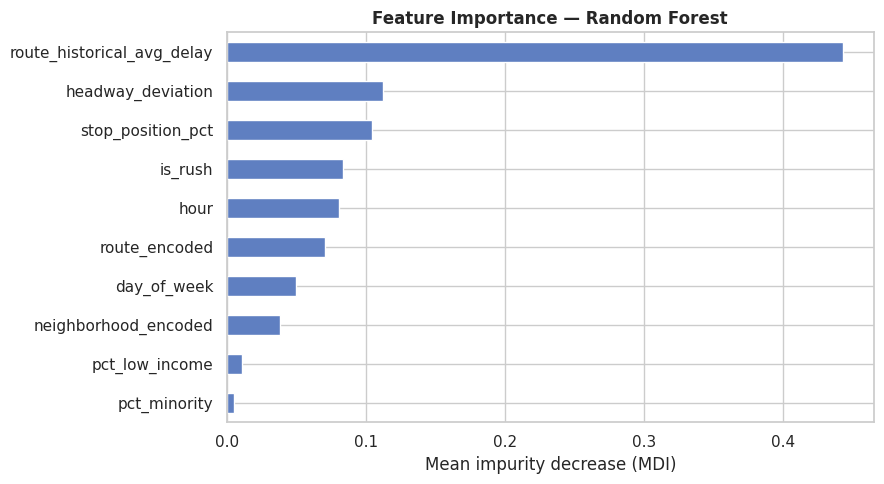

In [75]:
feat_imp = pd.Series(
    model.feature_importances_, index=FEATURES_FINAL
).sort_values(ascending=False)

print(f"\nFeature importances:\n{feat_imp.round(4).to_string()}")

fig, ax = plt.subplots(figsize=(9, 5))
feat_imp.plot(kind="barh", ax=ax, color="#5f7fc1")
ax.invert_yaxis()
ax.set_title("Feature Importance — Random Forest", fontweight="bold")
ax.set_xlabel("Mean impurity decrease (MDI)")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

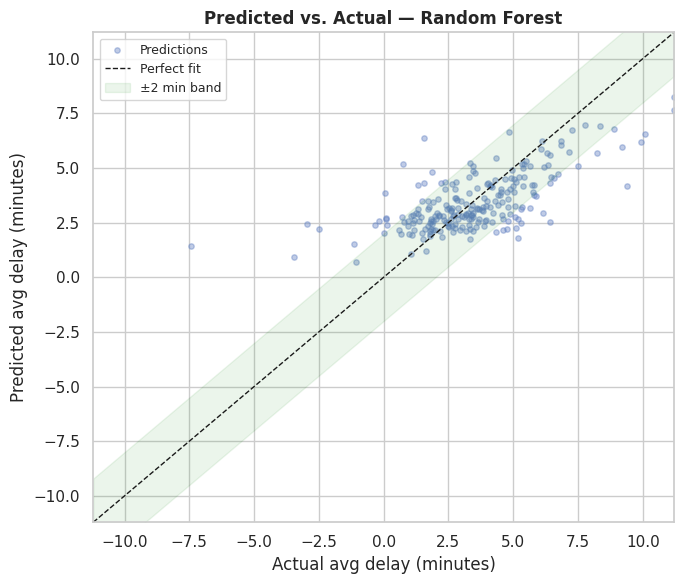

In [76]:
y_min = np.array(y_test) / 60
p_min = preds / 60
lim   = max(abs(y_min.min()), abs(y_min.max()))

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_min, p_min, alpha=0.4, s=15, color="#5f7fc1", label="Predictions")
ax.plot([-lim, lim], [-lim, lim], "k--", linewidth=1, label="Perfect fit")
ax.fill_between([-lim, lim], [-lim - 2, lim - 2], [-lim + 2, lim + 2],
                alpha=0.08, color="green", label="±2 min band")
ax.set_xlabel("Actual avg delay (minutes)")
ax.set_ylabel("Predicted avg delay (minutes)")
ax.set_title("Predicted vs. Actual — Random Forest", fontweight="bold")
ax.legend(fontsize=9)
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "rf_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

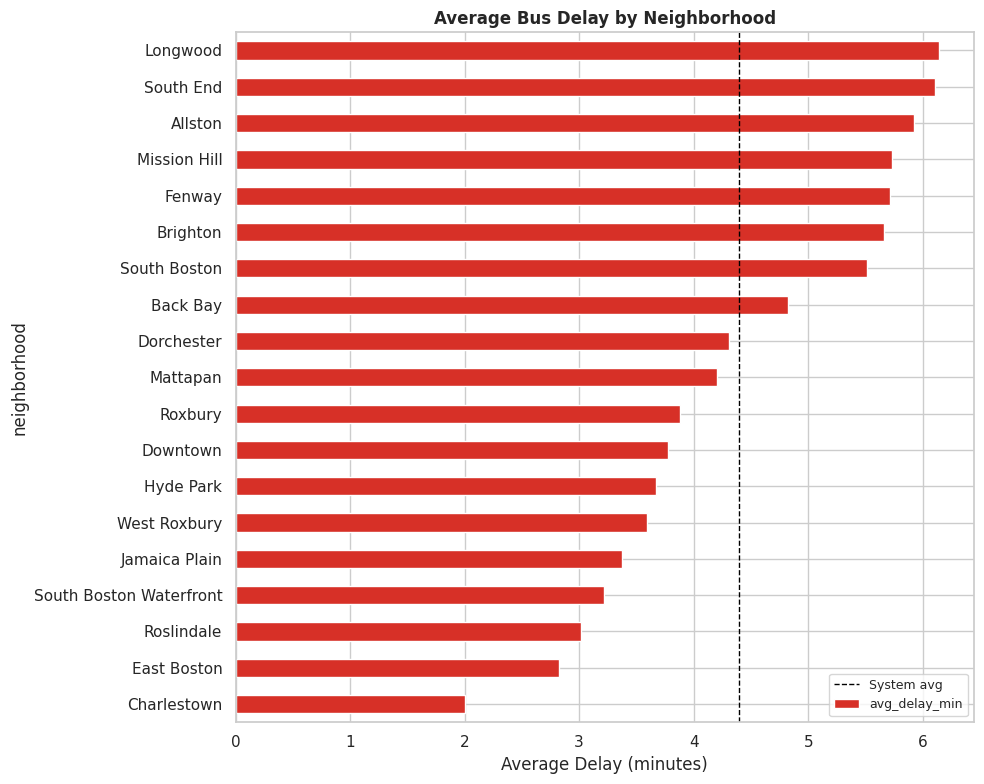

In [77]:
neighborhood_delays = (
    stop_df.groupby("neighborhood")[TARGET]
    .agg(avg_delay="mean", n="count")
    .query("n >= 5")
    .sort_values("avg_delay", ascending=False)
)
neighborhood_delays["avg_delay_min"] = (neighborhood_delays["avg_delay"] / 60).round(2)

plot_data = neighborhood_delays[neighborhood_delays.index != "Unknown"]

fig, ax = plt.subplots(figsize=(10, 8))
plot_data["avg_delay_min"].sort_values().plot(kind="barh", ax=ax, color="#d73027")
ax.axvline(plot_data["avg_delay_min"].mean(), color="black", linestyle="--",
           linewidth=1, label="System avg")
ax.set_xlabel("Average Delay (minutes)")
ax.set_title("Average Bus Delay by Neighborhood", fontweight="bold")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "rf_neighborhood_delays.png", dpi=150, bbox_inches="tight")
plt.show()


── Equity Disparity (by % Minority Riders) ──
  High minority stops avg delay : 3.45 min
  Low minority stops avg delay  : 3.85 min
  Time tax per trip             : -0.40 min
  Disparity ratio               : 0.90x


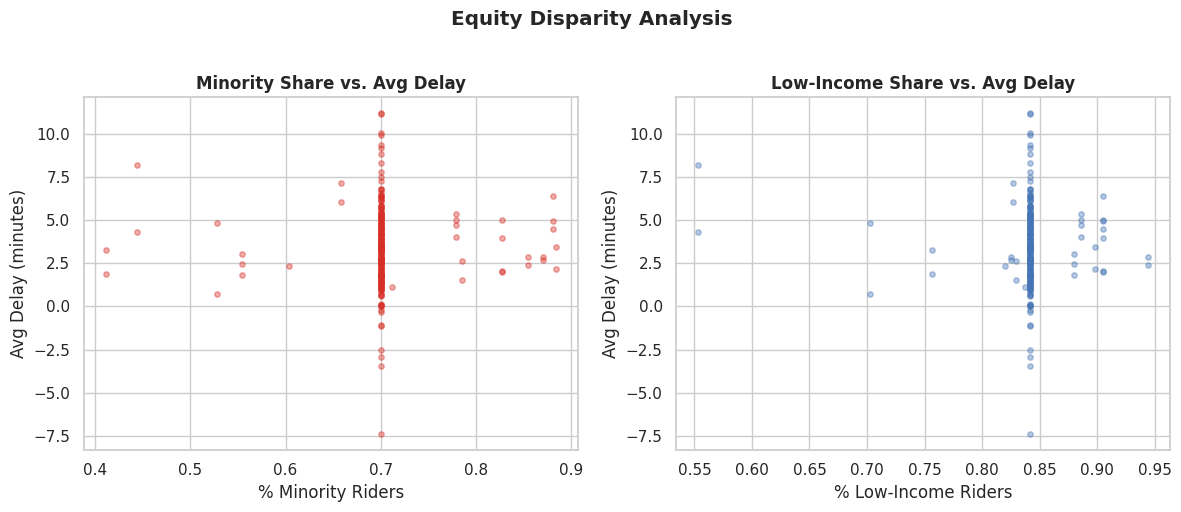

In [80]:
# ── 13. EQUITY DISPARITY ANALYSIS ────────────────────────────────────────────
# Compare average delay at stops with high vs low proportions of
# low-income and minority riders.

results_df = X_test.copy()
results_df["actual"]    = y_test.values
results_df["predicted"] = preds
results_df["residual"]  = results_df["actual"] - results_df["predicted"]

# Split by median pct_minority
median_minority = results_df["pct_minority"].median()
high = results_df[results_df["pct_minority"] >= median_minority]["actual"].mean()
low  = results_df[results_df["pct_minority"] <  median_minority]["actual"].mean()

print(f"\n── Equity Disparity (by % Minority Riders) ──")
print(f"  High minority stops avg delay : {high/60:.2f} min")
print(f"  Low minority stops avg delay  : {low/60:.2f} min")
print(f"  Time tax per trip             : {(high - low)/60:.2f} min")
print(f"  Disparity ratio               : {high/low:.2f}x")

# Scatter: pct_minority vs actual delay
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(results_df["pct_minority"], results_df["actual"] / 60,
                alpha=0.4, s=15, color="#d73027")
axes[0].set_xlabel("% Minority Riders")
axes[0].set_ylabel("Avg Delay (minutes)")
axes[0].set_title("Minority Share vs. Avg Delay", fontweight="bold")

axes[1].scatter(results_df["pct_low_income"], results_df["actual"] / 60,
                alpha=0.4, s=15, color="#4575b4")
axes[1].set_xlabel("% Low-Income Riders")
axes[1].set_ylabel("Avg Delay (minutes)")
axes[1].set_title("Low-Income Share vs. Avg Delay", fontweight="bold")

plt.suptitle("Equity Disparity Analysis", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "rf_equity_disparity.png", dpi=150, bbox_inches="tight")
plt.show()

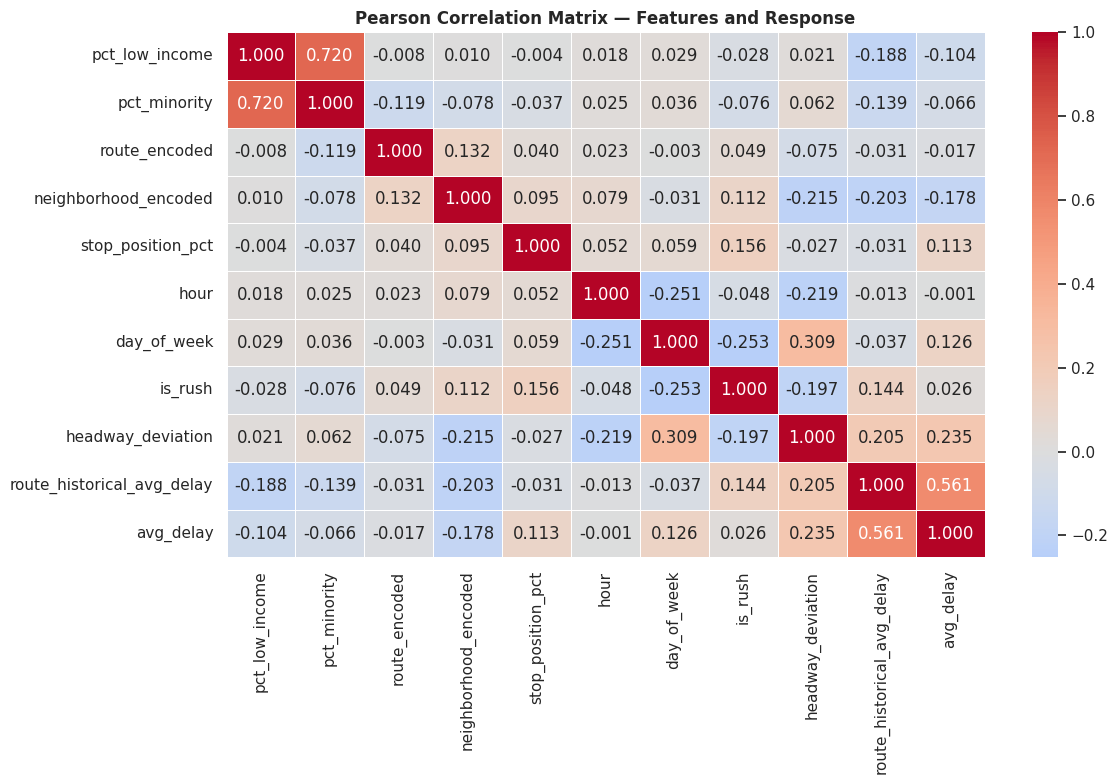

Correlations with avg_delay:
route_historical_avg_delay    0.561
headway_deviation             0.235
day_of_week                   0.126
stop_position_pct             0.113
is_rush                       0.026
hour                         -0.001
route_encoded                -0.017
pct_minority                 -0.066
pct_low_income               -0.104
neighborhood_encoded         -0.178

Multicollinearity check: cor(pct_minority, pct_low_income) = 0.720
  ⚠ High correlation — interpret those two coefficients jointly.


In [81]:
# ── 11. CORRELATION HEATMAP ───────────────────────────────────────────────────
# Pearson correlation between all numeric features and the response variable.
# Helps identify which features have the strongest linear relationship with avg_delay
# and flags potential multicollinearity between predictors.

corr_cols = FEATURES_FINAL + [TARGET]
corr_matrix = stop_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt=".3f",
    cmap="coolwarm", center=0,
    linewidths=0.5, linecolor="white",
    ax=ax
)
ax.set_title("Pearson Correlation Matrix — Features and Response", fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "rf_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Highlight key correlations with the response
corr_with_target = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlations with avg_delay:")
print(corr_with_target.round(3).to_string())

# Multicollinearity check
corr_demo = stop_df["pct_low_income"].corr(stop_df["pct_minority"])
print(f"\nMulticollinearity check: cor(pct_minority, pct_low_income) = {corr_demo:.3f}")
if abs(corr_demo) > 0.7:
    print("  ⚠ High correlation — interpret those two coefficients jointly.")

In [ ]:
# Adjusted R² accounts for the number of features — penalizes adding predictors
# that don't actually improve the model. More honest than regular R² for comparison.
n = len(y_test)
k = len(FEATURES_FINAL)
r2 = r2_score(y_test, final_preds)
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - k - 1)

print(f"  R²     : {r2:.4f}")
print(f"  Adj R² : {adj_r2:.4f}")
print(f"  n (test rows) : {n}")
print(f"  k (features)  : {k}")

In [ ]:
y_mean = y_test.mean()
SST    = ((y_test - y_mean) ** 2).sum()
SSE    = ((y_test - preds) ** 2).sum()
SSM    = SST - SSE
MSE    = SSE / (n - k - 1)
MSM    = SSM / k
F_stat = MSM / MSE
p_val  = stats.f.sf(F_stat, k, n - k - 1)

print(f"\n{'='*55}")
print("FINAL MODEL — STATISTICAL SUMMARY")
print(f"{'='*55}")
print(f"  n         = {n:,}")
print(f"  k         = {k}")
print(f"  MAE       = {mae:.2f} sec  ({mae/60:.3f} min)")
print(f"  RMSE      = {rmse:.2f} sec")
print(f"  R²        = {r2:.4f}")
print(f"  Adj R²    = {adj_r2:.4f}")
print(f"  F-stat    = {F_stat:.4f}")
print(f"  p-value   = {p_val:.4e}")
print(f"\n5-Fold CV MAE: {-cv_scores.mean():.2f} ± {cv_scores.std():.2f} sec")
print(f"\nFeature importances:")
print(feat_imp.round(4).to_string())